# 01 Binary Classifier — SP vs Non-SP

Goal: train and evaluate a CPP-based binary classifier that distinguishes signal peptide (SP) sequences from non-SP sequences.

Expected input: `data/processed/dataset_parsed.csv`, generated by `scripts/01_preprocess_signalp6.py`.

This notebook performs experiment-level filtering, train/test splitting, train-set balancing, CPP feature extraction, model training, and evaluation.


## 1. Imports and global settings

In [1]:
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import aaanalysis as aa

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

aa.options["verbose"] = False
aa.options["random_state"] = RANDOM_STATE


## 2. Paths and configuration

This clean pipeline uses the final thesis terminology:

- `pre_cs`: sequence region before the cleavage site
- `post_cs`: sequence region after the cleavage site
- `cs_position`: annotated cleavage-site position

The preprocessing step only parses the raw SignalP 6.0 dataset into tabular format. Filtering and balancing are performed explicitly inside this experiment pipeline.


In [2]:
# This notebook is expected to live in the notebooks/ folder.
# The fallback makes it work when launched from the project root as well.
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_parsed.csv"

FEATURE_DIR = PROJECT_ROOT / "features"
MODEL_DIR = PROJECT_ROOT / "models"
PLOT_DIR = PROJECT_ROOT / "plots"

for directory in [
    FEATURE_DIR / "metadata",
    FEATURE_DIR / "matrices",
    FEATURE_DIR / "indices",
    MODEL_DIR,
    PLOT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

MIN_PRE_CS_LEN = 5
POST_CS_LEN = 15
PRE_CS_LEN_FOR_PLOTS = 24
MAX_COR = 0.5

TEST_SIZE = 0.20
N_RUNS = 10

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)


Project root: /Users/jun/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Desktop_Kang/Uni/Master 1/signal_peptide_cpp
Dataset path: /Users/jun/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Desktop_Kang/Uni/Master 1/signal_peptide_cpp/data/processed/dataset_parsed.csv


## 3. Load parsed dataset

Required columns after preprocessing:

- `entry`
- `kingdom`
- `sp_type`
- `sequence`
- `annotation`
- `label_binary`
- `cs_position`
- `pre_cs`
- `post_cs`
- `pre_cs_len`
- `post_cs_len`


In [3]:
def load_parsed_dataset(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found: {path}")

    df = pd.read_csv(path)
    df = df.loc[:, ~df.columns.duplicated()].copy()

    required = [
        "entry",
        "kingdom",
        "sp_type",
        "sequence",
        "annotation",
        "label_binary",
        "cs_position",
        "pre_cs",
        "post_cs",
        "pre_cs_len",
        "post_cs_len",
    ]

    missing = [column for column in required if column not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df["label_binary"] = df["label_binary"].astype(int)
    df["cs_position"] = df["cs_position"].astype(int)
    df["pre_cs_len"] = df["pre_cs_len"].astype(int)
    df["post_cs_len"] = df["post_cs_len"].astype(int)
    df["pre_cs"] = df["pre_cs"].astype(str)
    df["post_cs"] = df["post_cs"].astype(str)

    return df


df_seq_raw = load_parsed_dataset(DATA_PATH)

print("Raw parsed dataset:", df_seq_raw.shape)
display(df_seq_raw.head())


Raw parsed dataset: (20290, 12)


,entry,kingdom,sp_type,record_index,sequence,annotation,label_binary,cs_position,pre_cs,post_cs,pre_cs_len,post_cs_len
0,Q8TF40,EUKARYA,NO_SP,0,MAPTLFQKLFSKRTGLGAPGRDARDPDCGFSWPLPEFDPSQIRLIV...,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,0,24,MAPTLFQKLFSKRTGLGAPGRDAR,DPDCGFSWPLPEFDP,24,15
1,Q1ENB6,EUKARYA,NO_SP,1,MDFTSLETTTFEEVVIALGSNVGNRMNNFKEALRLMKDYGISVTRH...,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,0,24,MDFTSLETTTFEEVVIALGSNVGN,RMNNFKEALRLMKDY,24,15
2,P36001,EUKARYA,NO_SP,2,MDDISGRQTLPRINRLLEHVGNPQDSLSILHIAGTNGKETVSKFLT...,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,0,24,MDDISGRQTLPRINRLLEHVGNPQ,DSLSILHIAGTNGKE,24,15
3,P55317,EUKARYA,NO_SP,0,MLGTVKMEGHETSDWNSYYADTQEAYSSVPVSNMNSGLGSMNSMNT...,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,0,24,MLGTVKMEGHETSDWNSYYADTQE,AYSSVPVSNMNSGLG,24,15
4,P35583,EUKARYA,NO_SP,0,MLGAVKMEGHEPSDWSSYYAEPEGYSSVSNMNAGLGMNGMNTYMSM...,IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII...,0,24,MLGAVKMEGHEPSDWSSYYAEPEG,YSSVSNMNAGLGMNG,24,15


## 4. Experiment-level filtering and sanity checks

For the final CPP setup, sequences with `pre_cs_len < 5` are removed so that the maximum CPP split of 5 remains valid. No balancing is performed here.


In [4]:
df_seq = (
    df_seq_raw[df_seq_raw["pre_cs_len"] >= MIN_PRE_CS_LEN]
    .copy()
    .reset_index(drop=True)
)

print("After filtering:", df_seq.shape)

print("\nBinary class counts:")
display(df_seq["label_binary"].value_counts().rename(index={0: "Non-SP", 1: "SP"}))

print("\nSP type counts:")
display(df_seq["sp_type"].value_counts())

print("\nKingdom counts:")
display(df_seq["kingdom"].value_counts())

print("\nLength summary by binary label:")
display(
    df_seq
    .groupby("label_binary")[["pre_cs_len", "post_cs_len"]]
    .describe()
)

print("\nLength summary by SP type:")
display(
    df_seq[df_seq["label_binary"] == 1]
    .groupby("sp_type")[["pre_cs_len", "post_cs_len"]]
    .describe()
)


After filtering: (20287, 12)

Binary class counts:


label_binary
Non-SP    15625
SP         4662
Name: count, dtype: int64


SP type counts:


sp_type
NO_SP      15625
SP          2582
LIPO        1615
TAT          365
PILIN         67
TATLIPO       33
Name: count, dtype: int64


Kingdom counts:


kingdom
EUKARYA     16396
NEGATIVE     2761
POSITIVE      935
ARCHAEA       195
Name: count, dtype: int64


Length summary by binary label:


pre_cs_len                                                     \
                  count       mean       std   min   25%   50%   75%   max   
label_binary                                                                 
0               15625.0  24.000000  0.000000  24.0  24.0  24.0  24.0  24.0   
1                4662.0  23.126341  7.171162   5.0  19.0  22.0  26.0  58.0   

             post_cs_len                                                     
                   count       mean       std   min   25%   50%   75%   max  
label_binary                                                                 
0                15625.0  15.000000  0.000000  15.0  15.0  15.0  15.0  15.0  
1                 4662.0  14.994423  0.109469  12.0  15.0  15.0  15.0  15.0


Length summary by SP type:


pre_cs_len                                                     \
             count       mean       std   min   25%   50%   75%   max   
sp_type                                                                 
LIPO        1615.0  20.334985  3.930923  11.0  17.0  20.0  22.0  36.0   
PILIN         67.0   9.626866  5.305331   5.0   7.0   7.0  11.5  25.0   
SP          2582.0  23.274206  6.142877   7.0  19.0  22.0  26.0  56.0   
TAT          365.0  36.649315  7.981626  26.0  31.0  33.0  44.0  58.0   
TATLIPO       33.0  26.000000  3.724916  21.0  23.0  25.0  28.0  38.0   

        post_cs_len                                                     
              count       mean       std   min   25%   50%   75%   max  
sp_type                                                                 
LIPO         1615.0  15.000000  0.000000  15.0  15.0  15.0  15.0  15.0  
PILIN          67.0  15.000000  0.000000  15.0  15.0  15.0  15.0  15.0  
SP           2582.0  14.998838  0.043999  13.0  15.0  15.0  15.0  15.0  
TAT           365.0  14.936986  0.368956  12.0  15.0  15.0  15.0  15.0  
TATLIPO        33.0  15.000000  0.000000  15.0  15.0  15.0  15.0  15.0

## 5. Train/test split and train-set balancing

The split is performed before balancing. Only the training set is balanced by randomly subsampling non-SP sequences. The test set is kept in its natural distribution.


In [5]:
train_df, test_df = train_test_split(
    df_seq,
    test_size=TEST_SIZE,
    stratify=df_seq["label_binary"],
    random_state=RANDOM_STATE,
)

train_sp = train_df[train_df["label_binary"] == 1]
train_nonsp = train_df[train_df["label_binary"] == 0].sample(
    n=len(train_sp),
    random_state=RANDOM_STATE,
)

train_balanced = (
    pd.concat([train_sp, train_nonsp], ignore_index=True)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

test_df = test_df.reset_index(drop=True)

y_train = train_balanced["label_binary"].to_numpy()
y_test = test_df["label_binary"].to_numpy()

np.save(FEATURE_DIR / "indices" / "test_entries_sp_vs_nonsp.npy", test_df["entry"].to_numpy())

print("Train full:", train_df["label_binary"].value_counts().to_dict())
print("Train balanced:", train_balanced["label_binary"].value_counts().to_dict())
print("Test:", test_df["label_binary"].value_counts().to_dict())


Train full: {0: 12500, 1: 3729}
Train balanced: {0: 3729, 1: 3729}
Test: {0: 3125, 1: 933}


## 6. Load amino-acid scales and create CPP features

CPP feature selection is performed only on the balanced training set.




In [6]:
df_scales = aa.load_scales()
sf = aa.SequenceFeature()

aac = aa.AAclust()
X_scales = np.array(df_scales).T
selected_scales = aac.fit(
    X_scales,
    names=list(df_scales),
    n_clusters=100,
).medoid_names_

df_scales = df_scales[selected_scales]

print(f"Selected scales: {len(df_scales.columns)}")


Selected scales: 100


### CPP split configuration

Custom split settings were used instead of the default AAanalysis split configuration.

The maximum segment split was limited to 5 to preserve short signal peptide types such as PILIN while still enabling segment-, pattern-, and periodic-pattern-based CPP feature extraction.

In [17]:
def to_cpp_parts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert thesis terminology to the part names expected by aaanalysis.CPP.
    Internally, CPP expects canonical part names such as 'tmd' and 'jmd_c'.
    In this project:
      - tmd   = pre_cs
      - jmd_c = post_cs
    """
    return df.rename(columns={"pre_cs": "tmd", "post_cs": "jmd_c"})[["tmd", "jmd_c"]].copy()


df_parts_train = to_cpp_parts(train_balanced)
df_parts_test = to_cpp_parts(test_df)

y_train = train_balanced["label_binary"].values
y_test = test_df["label_binary"].values

# pre-cs min length is 5, so n_split_max is 5 to avoid error from too short sequences when splitting. The n_split_min of 1 allows for no split, which is important for shorter sequences.

split_kws = {
    "Segment": {
        "n_split_min": 1,
        "n_split_max": 5
    },
    "Pattern": {
        "steps": [3, 4],  
        "n_min": 1,         
        "n_max": 2,         
        "len_max": 5          
    },
    "PeriodicPattern": {
        "steps": [3, 4]    
    }
}

cpp = aa.CPP(
    df_scales=df_scales,
    df_parts=df_parts_train,
    split_kws=split_kws,
    accept_gaps=True,
)

df_feat = cpp.run(
    labels=y_train,
    jmd_n_len=0,
    jmd_c_len=POST_CS_LEN,
    max_cor=MAX_COR,
)

aa.display_df(df_feat)

,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions
1,"TMD-Segment(3,4)-KOEH090102",Polarity,Hydrophilicity,Polarity (hydrophilicity),Hydrophobicity ...r et al. (2009),0.443000,0.267000,-0.267000,0.089000,0.141000,0.000000,0.000000,"11,12,13,14,15"
2,"TMD-Segment(3,4)-KYTJ820101",Polarity,Hydrophobicity,Hydrophobicity,"Hydropathy inde...oolittle, 1982)",0.436000,0.292000,0.292000,0.114000,0.148000,0.000000,0.000000,"11,12,13,14,15"
3,"TMD-Segment(2,3)-KOEH090102",Polarity,Hydrophilicity,Polarity (hydrophilicity),Hydrophobicity ...r et al. (2009),0.436000,0.254000,-0.254000,0.099000,0.125000,0.000000,0.000000,"7,8,9,10,11,12,13"
4,"TMD-Segment(2,3)-KYTJ820101",Polarity,Hydrophobicity,Hydrophobicity,"Hydropathy inde...oolittle, 1982)",0.431000,0.278000,0.278000,0.123000,0.131000,0.000000,0.000000,"7,8,9,10,11,12,13"
5,"TMD-Segment(2,2)-GUYH850104",ASA/Volume,Accessible surface area (ASA),Partition energy,"Apparent partit...dex (Guy, 1985)",0.429000,0.159000,-0.159000,0.061000,0.089000,0.000000,0.000000,"11,12,13,14,15,16,17,18,19,20"
6,"TMD-Segment(1,1)-FUKS010106",Composition,Membrane proteins (MPs),Proteins of mesophiles (INT),"Interior compos...ishikawa, 2001)",0.428000,0.158000,0.158000,0.073000,0.079000,0.000000,0.000000,"1,2,3,4,5,6,7,8...,16,17,18,19,20"
7,"TMD-Segment(2,3)-MIYS990105",Composition,MPs (anchor),Partition energy,"Optimized relat...Jernigan, 1999)",0.409000,0.239000,-0.239000,0.123000,0.123000,0.000000,0.000000,"7,8,9,10,11,12,13"
8,"TMD-Segment(3,4)-MIYS990105",Composition,MPs (anchor),Partition energy,"Optimized relat...Jernigan, 1999)",0.399000,0.242000,-0.242000,0.126000,0.138000,0.000000,0.000000,"11,12,13,14,15"
9,"TMD-Segment(3,4)-FAUJ880109",Energy,Isoelectric point,Number hydrogen bond donors,"Number of hydro...e et al., 1988)",0.394000,0.158000,-0.158000,0.070000,0.119000,0.000000,0.000000,"11,12,13,14,15"
10,"TMD-Segment(2,3)-LEVM780106",Conformation,β-turn,β-turn,"Normalized freq... (Levitt, 1978)",0.387000,0.178000,-0.178000,0.096000,0.116000,0.000000,0.000000,"7,8,9,10,11,12,13"


## 7. Build and save feature matrices

### CPP feature matrix generation

CPP-derived feature matrices were generated from the selected feature definitions and used as input for downstream machine learning classifiers.

### Training/test distribution

The training set was balanced by random subsampling of non-SP sequences after the train/test split.

The test set retained its original class distribution to provide a more realistic evaluation setting.

In [18]:
X_train = sf.feature_matrix(
    df_parts=df_parts_train,
    features=df_feat["feature"],
    accept_gaps=True,
)

X_test = sf.feature_matrix(
    df_parts=df_parts_test,
    features=df_feat["feature"],
    accept_gaps=True,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

# Save feature metadata
df_feat.to_csv(
    FEATURE_DIR / "metadata" / "features_sp_vs_nonsp.csv",
    index=False,
)

# Save feature matrices
np.save(
    FEATURE_DIR / "matrices" / "X_train_sp_vs_nonsp.npy",
    X_train,
)

np.save(
    FEATURE_DIR / "matrices" / "X_test_sp_vs_nonsp.npy",
    X_test,
)

np.save(
    FEATURE_DIR / "matrices" / "y_train_sp_vs_nonsp.npy",
    y_train,
)

np.save(
    FEATURE_DIR / "matrices" / "y_test_sp_vs_nonsp.npy",
    y_test,
)

X_train: (7458, 42)
X_test: (4058, 42)


## 8. Compare binary classifiers

Several classifiers were evaluated on the CPP-derived feature matrices over five independent runs with different random seeds.

For each run, models were trained on the balanced training set and evaluated on the original unbalanced test set. Mean performance and standard deviation were calculated across runs, and the F1-score comparison was visualized with error bars.

Model comparison:   0%|          | 0/10 [00:00<?, ?it/s]

/opt/miniconda3/envs/signalp_cpp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/signalp_cpp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/signalp_cpp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/signalp_cpp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/signalp_cpp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LG

,model,accuracy_mean,accuracy_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std
2,LightGBM,0.980532,0.000000,0.958574,0.000000,0.938398,0.000000,0.979636,0.000000
5,XGBoost,0.979596,0.000567,0.956613,0.001179,0.935825,0.001931,0.978349,0.001217
0,CatBoost,0.977871,0.000579,0.953147,0.001181,0.928634,0.002161,0.978992,0.001035
1,ExtraTrees,0.961483,0.000637,0.918819,0.001270,0.891369,0.002255,0.948017,0.001360
4,Random Forest,0.960917,0.000509,0.917619,0.001027,0.890246,0.001572,0.946731,0.000882
3,Logistic Regression,0.929768,0.000000,0.859259,0.000000,0.796703,0.000000,0.932476,0.000000


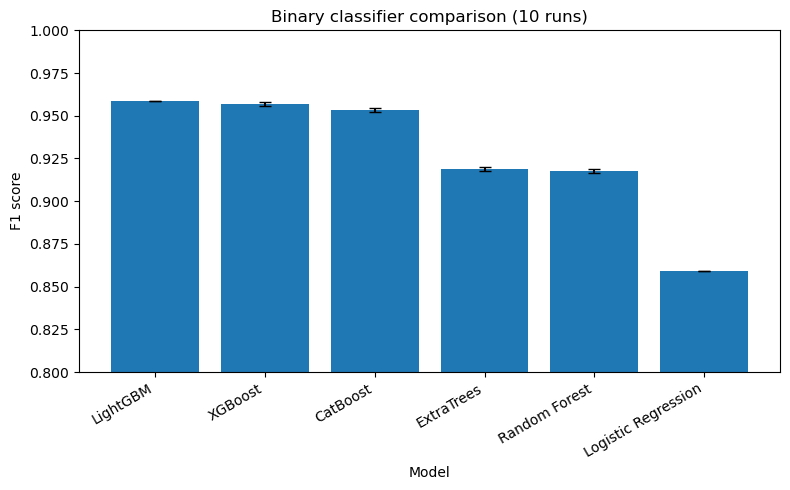

Saved summary to: /Users/jun/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Desktop_Kang/Uni/Master 1/signal_peptide_cpp/results/metrics/binary_model_comparison_summary.csv
Saved run-level results to: /Users/jun/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Desktop_Kang/Uni/Master 1/signal_peptide_cpp/results/metrics/binary_model_comparison_runs.csv
Saved plot to: /Users/jun/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Desktop_Kang/Uni/Master 1/signal_peptide_cpp/plots/binary_model_f1_comparison.png


In [22]:
## 8. Compare binary classifiers over repeated runs

N_RUNS = 10

METRIC_DIR = PROJECT_ROOT / "results" / "metrics"
METRIC_DIR.mkdir(parents=True, exist_ok=True)

PLOT_DIR.mkdir(parents=True, exist_ok=True)


def get_models(seed: int):
    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=seed,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=seed,
            n_jobs=-1,
        ),
        "ExtraTrees": ExtraTreesClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=seed,
            n_jobs=-1,
        ),
    }

    if XGBClassifier is not None:
        models["XGBoost"] = XGBClassifier(
            n_estimators=800,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=seed,
            eval_metric="logloss",
            n_jobs=-1,
        )

    if LGBMClassifier is not None:
        models["LightGBM"] = LGBMClassifier(
            n_estimators=800,
            learning_rate=0.05,
            class_weight="balanced",
            random_state=seed,
            n_jobs=-1,
            verbose=-1,
        )

    if CatBoostClassifier is not None:
        models["CatBoost"] = CatBoostClassifier(
            iterations=800,
            learning_rate=0.05,
            depth=6,
            random_state=seed,
            verbose=False,
        )

    return models


def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
    }


rows = []

for run_idx in tqdm(range(N_RUNS), desc="Model comparison"):
    seed = RANDOM_STATE + run_idx

    for model_name, model in get_models(seed).items():
        metrics = evaluate_model(
            model,
            X_train,
            y_train,
            X_test,
            y_test,
        )

        rows.append(
            {
                "run": run_idx,
                "model": model_name,
                **metrics,
            }
        )


results = pd.DataFrame(rows)

summary = (
    results
    .groupby("model")
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
    )
    .reset_index()
    .sort_values("f1_mean", ascending=False)
)

summary_path = METRIC_DIR / "binary_model_comparison_summary.csv"
results_path = METRIC_DIR / "binary_model_comparison_runs.csv"

summary.to_csv(summary_path, index=False)
results.to_csv(results_path, index=False)

display(summary)


plot_df = summary.sort_values("f1_mean", ascending=False).copy()

plt.figure(figsize=(8, 5))

plt.bar(
    plot_df["model"],
    plot_df["f1_mean"],
    yerr=plot_df["f1_std"],
    capsize=4,
)

plt.ylabel("F1 score")
plt.xlabel("Model")
plt.title(f"Binary classifier comparison ({N_RUNS} runs)")
plt.ylim(0.80, 1.00)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plot_path = PLOT_DIR / "binary_model_f1_comparison.png"

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved summary to: {summary_path}")
print(f"Saved run-level results to: {results_path}")
print(f"Saved plot to: {plot_path}")

## 9. Train final binary classifier

### Final model selection

Several classifiers showed highly comparable performance on the CPP-derived feature matrices.

Although LightGBM achieved a slightly higher mean F1-score in the repeated benchmark runs, XGBoost was selected as the final binary classifier for consistency with the thesis results and because the performance differences between the top ensemble models were marginal.

The final model was retrained on the balanced training set and evaluated on the original unbalanced test set. The trained classifier was then saved for downstream inference and end-to-end pipeline evaluation.

In [23]:
if XGBClassifier is not None:
    final_model_name = "XGBoost"
    final_model = XGBClassifier(
        n_estimators=800,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=-1,
    )
else:
    final_model_name = "Random Forest"
    final_model = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1] if hasattr(final_model, "predict_proba") else None

print(final_model_name)
print(classification_report(y_test, y_pred, target_names=["Non-SP", "SP"], digits=4))

joblib.dump(final_model, MODEL_DIR / "model_sp_vs_nonsp.pkl")


XGBoost
              precision    recall  f1-score   support

      Non-SP     0.9932    0.9792    0.9861      3125
          SP     0.9335    0.9775    0.9550       933

    accuracy                         0.9788      4058
   macro avg     0.9633    0.9783    0.9706      4058
weighted avg     0.9795    0.9788    0.9790      4058



['/Users/jun/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Desktop_Kang/Uni/Master 1/signal_peptide_cpp/models/model_sp_vs_nonsp.pkl']

## 10. Confusion matrix

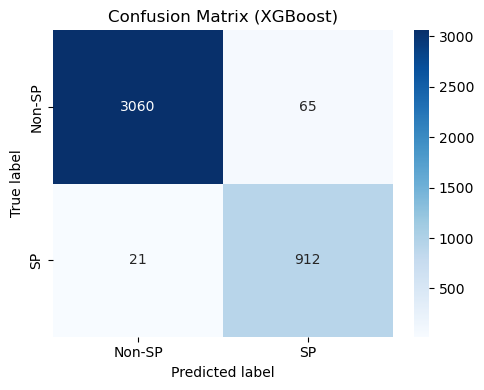

In [26]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Non-SP", "SP"],
    columns=["Non-SP", "SP"],
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix ({final_model_name})")

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "binary_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 11. Error analysis by SP type and kingdom

In [31]:
def grouped_binary_metrics(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    rows = []

    for group_value, sub in df.groupby(group_col):
        y_true_g = sub["y_true"]
        y_pred_g = sub["y_pred"]

        rows.append(
            {
                group_col: group_value,
                "n": len(sub),
                "accuracy": accuracy_score(y_true_g, y_pred_g),
                "precision_sp": precision_score(y_true_g, y_pred_g, zero_division=0),
                "recall_sp": recall_score(y_true_g, y_pred_g, zero_division=0),
                "f1_sp": f1_score(y_true_g, y_pred_g, zero_division=0),
                "error_rate": (y_true_g != y_pred_g).mean(),
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values("f1_sp", ascending=False)
        .reset_index(drop=True)
    )


metrics_by_type = grouped_binary_metrics(eval_df, "sp_type")
metrics_by_kingdom = grouped_binary_metrics(eval_df, "kingdom")

metrics_by_type.to_csv(METRIC_DIR / "binary_metrics_by_sp_type.csv", index=False)
metrics_by_kingdom.to_csv(METRIC_DIR / "binary_metrics_by_kingdom.csv", index=False)

display(metrics_by_type)
display(metrics_by_kingdom)

,sp_type,n,accuracy,precision_sp,recall_sp,f1_sp,error_rate
0,LIPO,312,1.000000,1.0,1.000000,1.000000,0.000000
1,SP,529,0.977316,1.0,0.977316,0.988528,0.022684
2,TAT,69,0.942029,1.0,0.942029,0.970149,0.057971
3,TATLIPO,7,0.857143,1.0,0.857143,0.923077,0.142857
4,PILIN,16,0.750000,1.0,0.750000,0.857143,0.250000
5,NO_SP,3125,0.979200,0.0,0.000000,0.000000,0.020800


,kingdom,n,accuracy,precision_sp,recall_sp,f1_sp,error_rate
0,POSITIVE,178,0.983146,0.985294,0.992593,0.988930,0.016854
1,NEGATIVE,561,0.951872,0.948649,0.977716,0.962963,0.048128
2,EUKARYA,3280,0.983537,0.903509,0.976303,0.938497,0.016463
3,ARCHAEA,39,0.948718,1.000000,0.882353,0.937500,0.051282


### Group-level evaluation

The following plots are based on the final trained XGBoost binary classifier, not on the repeated benchmark averages.

Performance was analyzed by signal peptide type and taxonomic kingdom to identify group-specific error patterns.

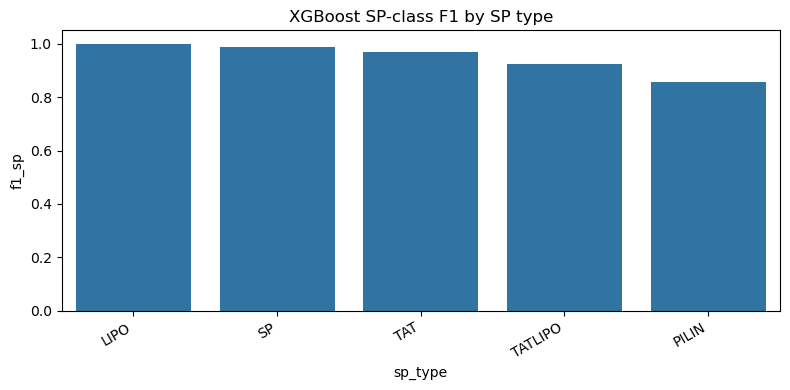

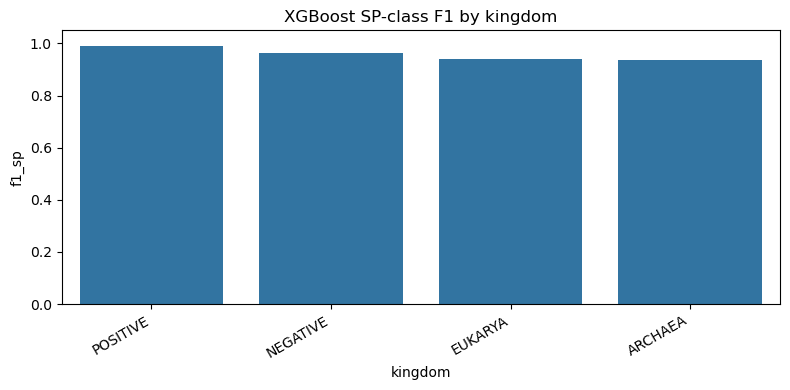

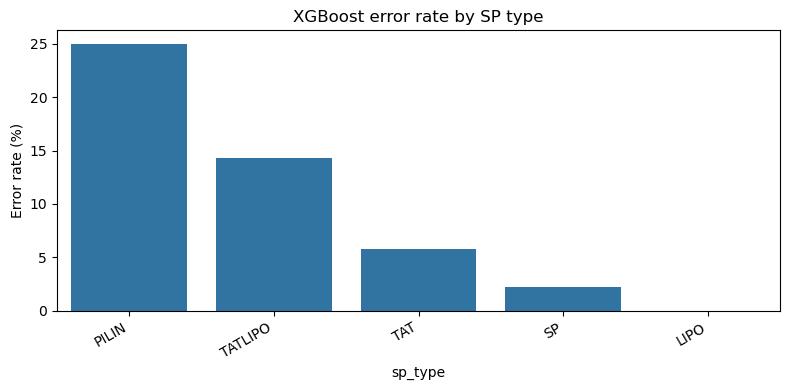

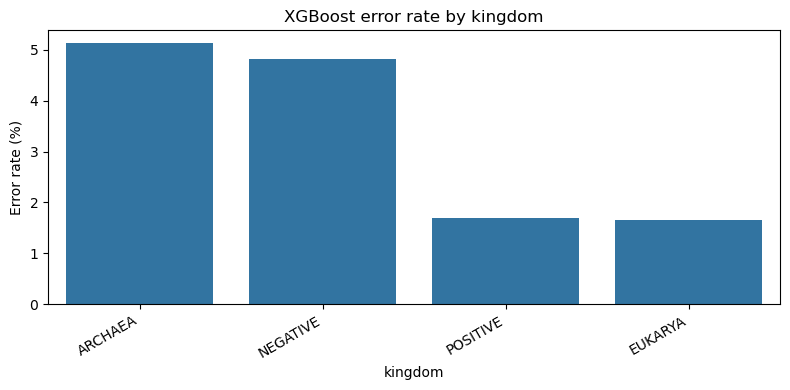

In [33]:
## Group-level performance plots for final binary classifier

# SP type plot에서는 NO_SP 제외
metrics_by_type_sp_only = metrics_by_type[
    metrics_by_type["sp_type"] != "NO_SP"
].copy()

metrics_by_type_sp_only["error_rate_pct"] = metrics_by_type_sp_only["error_rate"] * 100
metrics_by_kingdom["error_rate_pct"] = metrics_by_kingdom["error_rate"] * 100


def plot_grouped_score(
    df: pd.DataFrame,
    group_col: str,
    metric: str,
    title: str,
    filename: str,
):
    plot_df = df.sort_values(metric, ascending=False)

    plt.figure(figsize=(8, 4))

    sns.barplot(
        data=plot_df,
        x=group_col,
        y=metric,
    )

    plt.ylabel(metric)
    plt.xlabel(group_col)
    plt.title(title)
    plt.ylim(0, 1.05)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(PLOT_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


def plot_error_rate_pct(
    df: pd.DataFrame,
    group_col: str,
    title: str,
    filename: str,
):
    plot_df = df.sort_values("error_rate_pct", ascending=False)

    plt.figure(figsize=(8, 4))

    sns.barplot(
        data=plot_df,
        x=group_col,
        y="error_rate_pct",
    )

    plt.ylabel("Error rate (%)")
    plt.xlabel(group_col)
    plt.title(title)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(PLOT_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


plot_grouped_score(
    metrics_by_type_sp_only,
    "sp_type",
    "f1_sp",
    f"{final_model_name} SP-class F1 by SP type",
    "binary_f1_by_sp_type.png",
)

plot_grouped_score(
    metrics_by_kingdom,
    "kingdom",
    "f1_sp",
    f"{final_model_name} SP-class F1 by kingdom",
    "binary_f1_by_kingdom.png",
)

plot_error_rate_pct(
    metrics_by_type_sp_only,
    "sp_type",
    f"{final_model_name} error rate by SP type",
    "binary_error_rate_by_sp_type.png",
)

plot_error_rate_pct(
    metrics_by_kingdom,
    "kingdom",
    f"{final_model_name} error rate by kingdom",
    "binary_error_rate_by_kingdom.png",
)

## 12. CPP feature importance analysis

Feature importance scores were estimated using the AAanalysis TreeModel wrapper to identify the most discriminative CPP-derived physicochemical descriptors between SP and non-SP sequences.


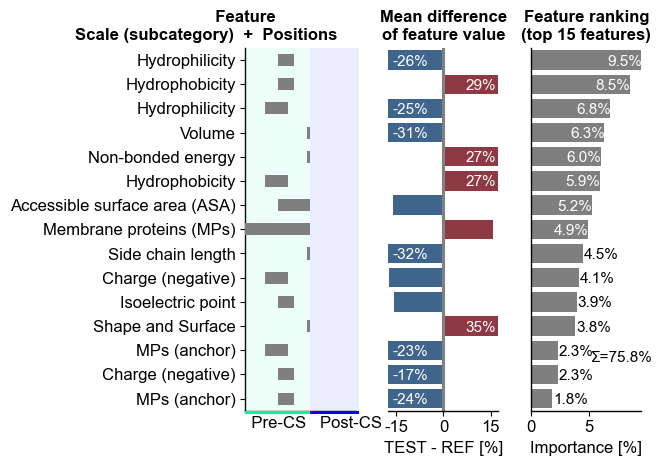

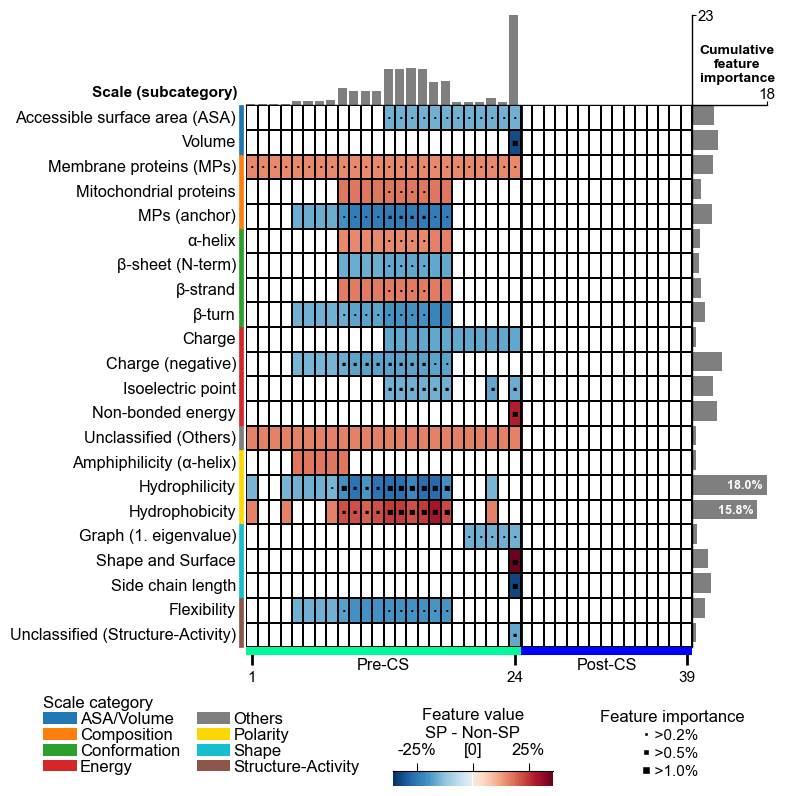

In [43]:
import aaanalysis.utils as ut

# Include group level feature importance
tm = aa.TreeModel()
tm.fit(X_train, labels=y_train)
df_feat = tm.add_feat_importance(df_feat=df_feat, drop=True)

# Rename CPP internal part labels for signal peptide analysis
ut.options["name_tmd"] = "Pre-CS"
ut.options["name_jmd_c"] = "Post-CS"
ut.options["name_jmd_n"] = ""

cpp_plot = aa.CPPPlot(
    jmd_n_len=0,
    jmd_c_len=POST_CS_LEN,
)

aa.plot_settings(
    short_ticks=True,
    weight_bold=False,
)

# CPP feature ranking
cpp_plot.ranking(
    df_feat=df_feat
    )


plt.tight_layout()
plt.savefig(
    PLOT_DIR / "cpp_feature_ranking_sp_vs_nonsp.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# CPP feature map
ut.options["name_tmd"] = "Pre-CS"
ut.options["name_jmd_c"] = "Post-CS"
ut.options["name_jmd_n"] = ""

cpp_plot = aa.CPPPlot(
    jmd_n_len=0,
    jmd_c_len=POST_CS_LEN,
)

aa.plot_settings(
    font_scale=0.65,
    weight_bold=False,
)

cpp_plot.feature_map(
    df_feat=df_feat,
    tmd_len=PRE_CS_LEN_FOR_PLOTS,
    name_test="SP",
    name_ref="Non-SP"
)

plt.tight_layout()
plt.savefig(
    PLOT_DIR / "cpp_feature_map_sp_vs_nonsp.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

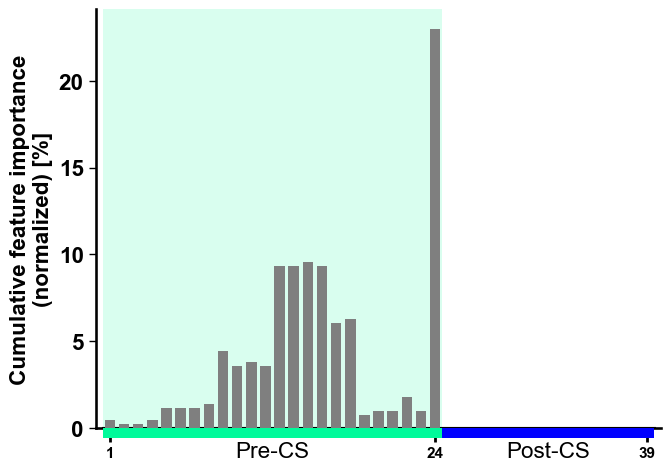

In [44]:
# Plot CPP profile
aa.plot_settings(font_scale=0.9)
cpp_plot.profile(df_feat=df_feat, tmd_len=24)
plt.show()

## 13. Final experiment summary

The final experiment configuration and evaluation metrics were saved to disk for reproducibility and downstream analysis.

In [45]:
## Final experiment summary

final_metrics = {
    "model": final_model_name,

    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),

    "n_train": int(len(y_train)),
    "n_test": int(len(y_test)),
    "n_features": int(X_train.shape[1]),

    "min_pre_cs_len": MIN_PRE_CS_LEN,
    "post_cs_len": POST_CS_LEN,

    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "n_runs_benchmark": N_RUNS,
}

metrics_path = METRIC_DIR / "binary_final_metrics.json"

with open(metrics_path, "w") as file:
    json.dump(final_metrics, file, indent=2)

print(f"Saved final metrics to: {metrics_path}")

final_metrics

Saved final metrics to: /Users/jun/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Desktop_Kang/Uni/Master 1/signal_peptide_cpp/results/metrics/binary_final_metrics.json


{'model': 'XGBoost',
 'accuracy': 0.9788072942336126,
 'precision': 0.9334698055271239,
 'recall': 0.977491961414791,
 'f1': 0.9549738219895288,
 'n_train': 7458,
 'n_test': 4058,
 'n_features': 42,
 'min_pre_cs_len': 5,
 'post_cs_len': 15,
 'test_size': 0.2,
 'random_state': 42,
 'n_runs_benchmark': 10}